# Statistical Analysis

# Reproducibility

- **Generated at:** `2026-08-06T04:51:08.329076+00:00`
- **Code/commit reference:** `aa84a065ffa36b58a3f8f8b2b8523d7dad07a45c`
- **Dataset row counts used:** orders=99,441, payments=103,886, order_items=112,650, customers=99,441, customer_profile=93,358, reviews=99,224
- **Metric contract:** delivered orders only for revenue, orders, customers, AOV, and historical CLV; purchase timestamp is the date axis.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from app.services.stats_service import run_statistical_analysis
from app.services.customer_analytics_service import customer_analytics
stats_result = await run_statistical_analysis()
customers = await customer_analytics()

In [2]:
pd.DataFrame(stats_result['descriptive_statistics']).set_index('field')

,count,mean,median,mode,variance,std,q1,q3,min,max
field,,,,,,,,,,
price,112650,120.653739,74.99,59.9,33721.419531,183.633928,39.90,134.9000,0.85,6735.00
freight_value,112650,19.990320,16.26,15.1,249.842452,15.806405,13.08,21.1500,0.00,409.68
payment_value,103886,154.100380,100.00,50.0,47303.667816,217.494064,56.79,171.8375,0.00,13664.08
delivery_days,96476,12.094086,10.00,7.0,91.235854,9.551746,6.00,15.0000,0.00,209.00
review_score,98410,4.088802,5.00,5.0,1.811064,1.345758,4.00,5.0000,1.00,5.00


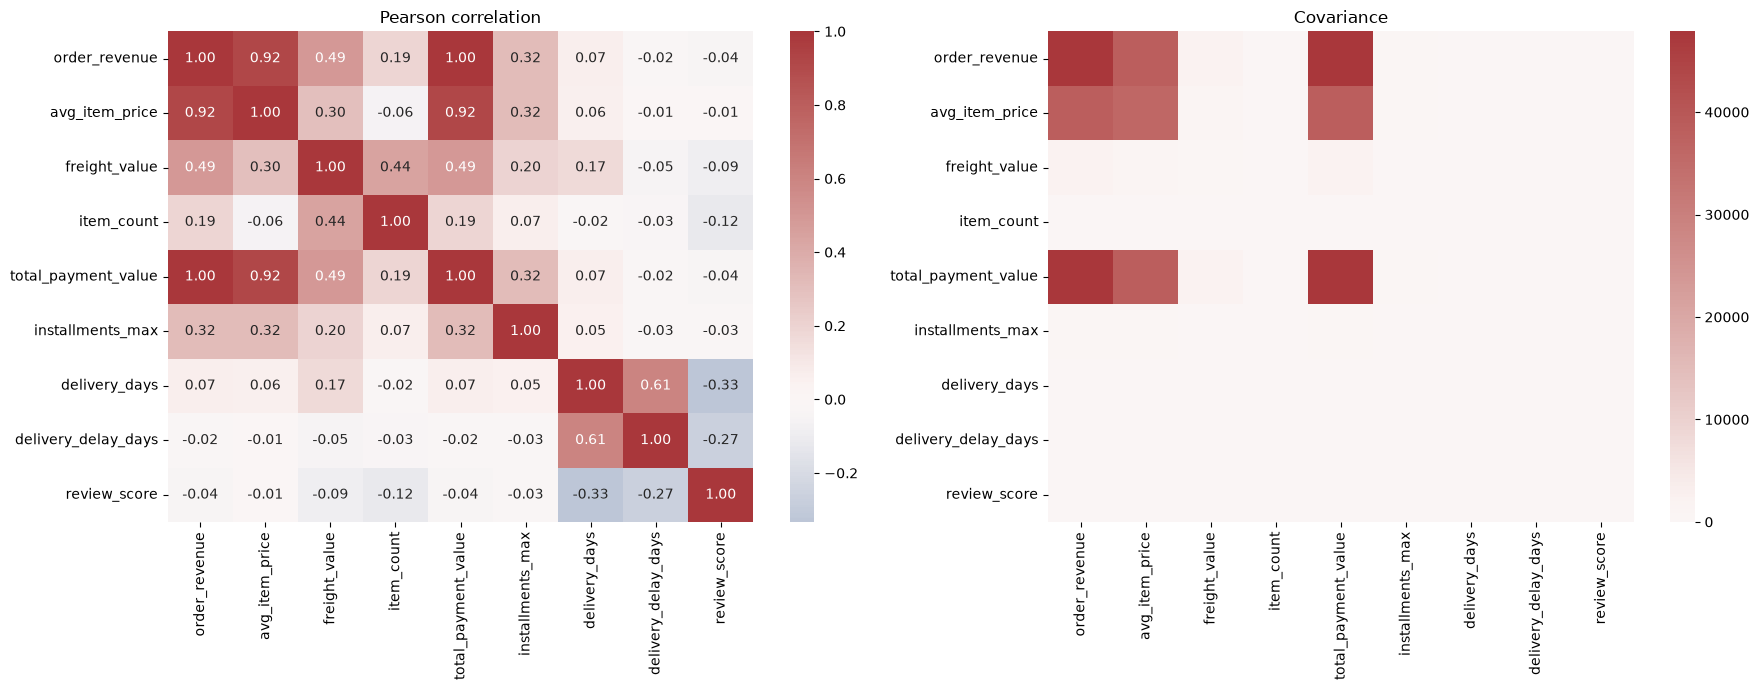

In [3]:
corr = pd.DataFrame(stats_result['matrices']['correlation'])
cov = pd.DataFrame(stats_result['matrices']['covariance'])
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr, cmap='vlag', center=0, ax=axes[0], annot=True, fmt='.2f')
axes[0].set_title('Pearson correlation')
sns.heatmap(cov, cmap='vlag', center=0, ax=axes[1])
axes[1].set_title('Covariance')
plt.tight_layout()

In [4]:
pd.DataFrame(stats_result['hypothesis_tests'])[['name', 'statistic', 'f_statistic', 't_statistic', 'p_value', 'conclusion']].fillna('')

,name,statistic,f_statistic,t_statistic,p_value,conclusion
0,Chi-Square: primary payment type × customer se...,393.833637,,,1.365584e-74,The association between primary payment method...
1,One-way ANOVA: delivery days across customer s...,,781.840644,,0.000000e+00,Differences in mean delivery time across state...
2,Welch T-Test: review score for on-time vs late...,,,89.550711,0.000000e+00,Late deliveries have a lower mean review score...


## Customer analytics evidence

In [5]:
pd.Series(customers['overview'])

customers                   93358.000000
repeat_customers             2801.000000
repeat_purchase_rate_pct        3.000278
avg_order_count                 1.033420
avg_clv                       165.168210
median_clv                    107.780000
dtype: float64

In [6]:
pd.DataFrame(customers['segments'])

,segment,customer_count,avg_clv,avg_order_count
0,Hibernating,36347,161.8133163672380114,1.00000000000000000000
1,New,36140,164.3102194244604317,1.00000000000000000000
2,Promising,18070,151.4104233536247925,1.00000000000000000000
3,At Risk,996,293.8703112449799197,2.0813253012048193
4,Champions,985,372.4612588832487310,2.1817258883248731
5,Loyal,820,249.5345000000000000,2.0719512195121951


In [7]:
pd.Series(customers['time_between_orders'])

gaps                          3120.000000
avg_days_between_orders         79.150268
median_days_between_orders      29.455527
dtype: float64